# Exploratory Data Analysis — Netflix Prize Dataset

**Project:** Recommendation Systems for Personalized Content Discovery

This notebook covers Mandatory Task A: a detailed analysis of the dataset
identifying **user activity patterns**, **content popularity trends**,
**rating distributions** and **data sparsity characteristics**, followed by the
key insights that motivate our modelling choices.

The full Netflix Prize dataset has **100,480,507 ratings** from **480,189 users**
on **17,770 movies** (Oct 1998 – Dec 2005), split across four `combined_data_*.txt`
files (~2 GB). We analyse
`combined_data_1.txt` (~24M ratings, ~471k users, 4,499 movies) — a
representative ~24% slice — and report full-dataset figures from the README where
relevant. The brief explicitly permits working on a subset.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data import paths
from data.preprocess import load_ratings_file, get_movie_titles

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)

FIG_DIR = paths.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
def save(name): 
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")

## 1. Load the data
Parse the colon-delimited raw file into a compact columnar table (user/movie/rating/date).

In [4]:
ratings = load_ratings_file(paths.COMBINED_FILES[0])
titles = get_movie_titles()
print(f"Ratings : {len(ratings):,}")
print(f"Users   : {ratings['user_id'].nunique():,}")
print(f"Movies  : {ratings['movie_id'].nunique():,}")
print(f"Memory  : {ratings.memory_usage(deep=True).sum()/1e6:.0f} MB")
ratings.head()

Ratings : 24,053,764
Users   : 470,758
Movies  : 4,499
Memory  : 409 MB


,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [5]:
print("Date range :", ratings['date'].min().date(), "->", ratings['date'].max().date())
print("Mean rating:", round(ratings['rating'].mean(), 3))
print("Std rating :", round(ratings['rating'].std(), 3))
ratings['rating'].describe()

Date range : 1999-11-11 -> 2005-12-31
Mean rating: 3.6
Std rating : 1.086


count    2.405376e+07
mean     3.599634e+00
std      1.086118e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

## 2. Rating distribution
How are the 1–5 star ratings distributed?

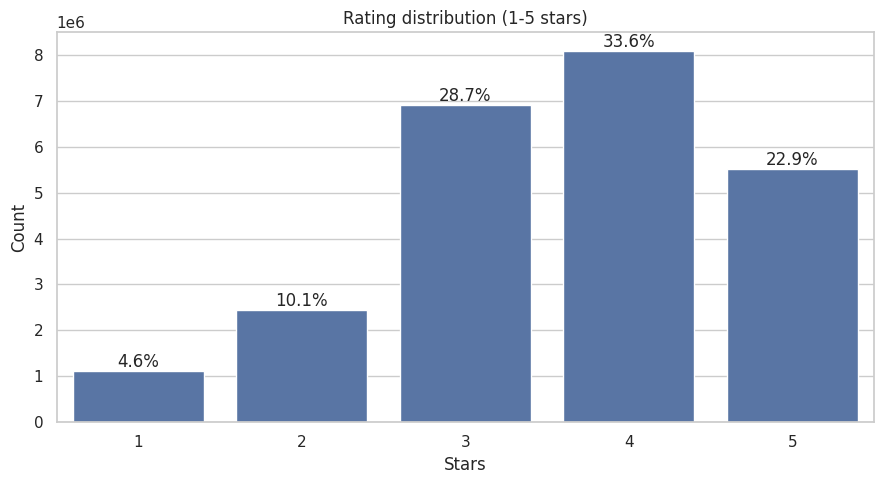

rating
1    0.0465
2    0.1014
3    0.2870
4    0.3362
5    0.2289


In [6]:
counts = ratings['rating'].value_counts().sort_index()
ax = sns.barplot(x=counts.index, y=counts.values)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v/len(ratings):.1%}", ha="center", va="bottom")
plt.title("Rating distribution (1-5 stars)"); plt.xlabel("Stars"); plt.ylabel("Count")
save("rating_distribution.png"); plt.show()
print((counts / len(ratings)).round(4).to_string())

**Observation.** Ratings are skewed positive: 3 and 4 stars dominate and the
mean sits near ~3.6. Users mostly rate films they chose to watch, so low ratings
are comparatively rare — a strong, simple baseline must therefore predict close
to the high global mean. Note the relevance threshold for ranking (rating ≥ 3.5)
classifies 4- and 5-star ratings as *relevant*.

## 3. User activity patterns
How many ratings does each user contribute?

In [7]:
user_counts = ratings.groupby('user_id').size()
print(user_counts.describe().round(1).to_string())
print("\nMedian ratings/user:", int(user_counts.median()))
print("Top 1% of users contribute:",
      f"{user_counts.nlargest(int(len(user_counts)*0.01)).sum()/len(ratings):.2%} of all ratings")

count    470758.0
mean         51.1
std          74.4
min           1.0
25%           8.0
50%          24.0
75%          64.0
max        4467.0

Median ratings/user: 24
Top 1% of users contribute: 9.14% of all ratings


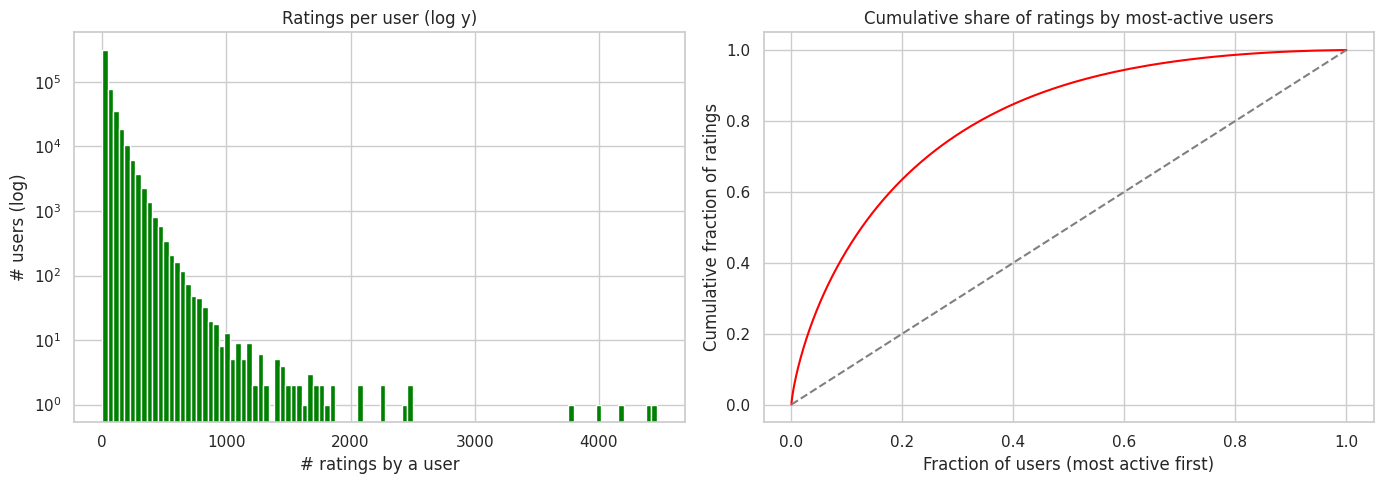

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(user_counts, bins=100, color="green")
ax[0].set_yscale("log"); ax[0].set_title("Ratings per user (log y)")
ax[0].set_xlabel("# ratings by a user"); ax[0].set_ylabel("# users (log)")

# Lorenz-style cumulative contribution curve
sorted_counts = np.sort(user_counts.values)[::-1]
cum = np.cumsum(sorted_counts) / sorted_counts.sum()
ax[1].plot(np.arange(len(cum))/len(cum), cum, color="red")
ax[1].plot([0,1],[0,1], "--", color="grey")
ax[1].set_title("Cumulative share of ratings by most-active users")
ax[1].set_xlabel("Fraction of users (most active first)")
ax[1].set_ylabel("Cumulative fraction of ratings")
save("user_activity.png"); plt.show()

**Observation.** User activity is **highly skewed / long-tailed**: most users
rate relatively few movies while a small minority of power-users account for a
large share of all ratings (the cumulative curve bows far above the diagonal).
This motivates (a) filtering out very low-activity users for stable collaborative
filtering and (b) regularising user terms by their support count.

## 4. Content popularity trends
How are ratings distributed across movies?

count      4499.0
mean       5346.5
std       16176.3
min          36.0
25%         192.0
50%         552.0
75%        2538.0
max      193941.0


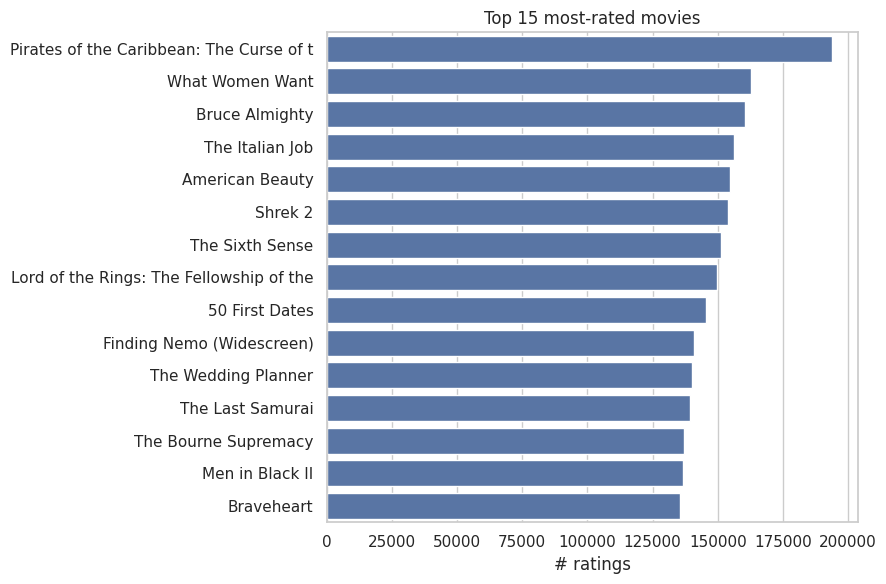

In [9]:
movie_counts = ratings.groupby('movie_id').size()
print(movie_counts.describe().round(1).to_string())
top = movie_counts.nlargest(15).rename("n_ratings").reset_index().merge(titles, on="movie_id")
top["label"] = top["title"].str.slice(0, 40)
plt.figure(figsize=(9,6))
sns.barplot(y="label", x="n_ratings", data=top, color="#4C72B0")
plt.title("Top 15 most-rated movies"); plt.xlabel("# ratings"); plt.ylabel("")
save("top_movies.png"); plt.show()

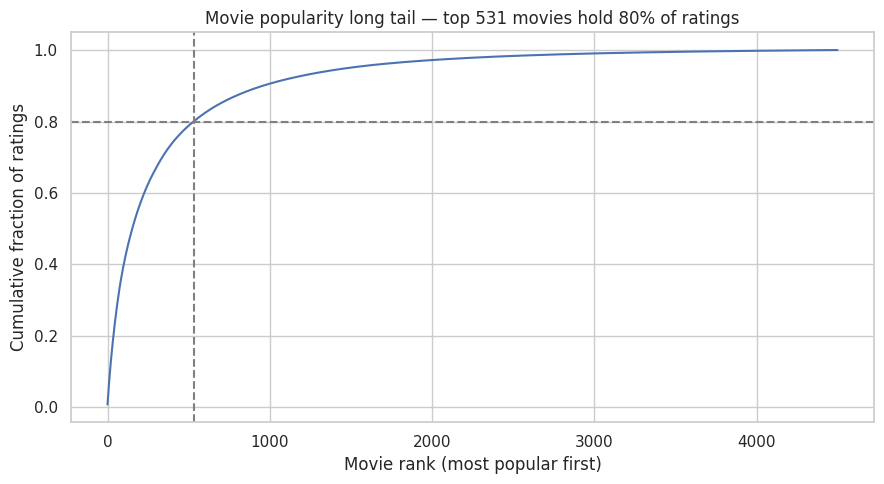

531 of 4499 movies (11.8%) account for 80% of ratings


In [10]:
sorted_m = np.sort(movie_counts.values)[::-1]
cum_m = np.cumsum(sorted_m) / sorted_m.sum()
plt.plot(np.arange(len(cum_m)), cum_m)
plt.axhline(0.8, ls="--", color="grey")
n80 = int(np.searchsorted(cum_m, 0.8)) + 1
plt.axvline(n80, ls="--", color="grey")
plt.title(f"Movie popularity long tail — top {n80} movies hold 80% of ratings")
plt.xlabel("Movie rank (most popular first)"); plt.ylabel("Cumulative fraction of ratings")
save("popularity_longtail.png"); plt.show()
print(f"{n80} of {len(movie_counts)} movies ({n80/len(movie_counts):.1%}) account for 80% of ratings")

**Observation.** Popularity follows a classic **long tail**: a small set of
blockbuster titles captures the bulk of ratings, while thousands of niche movies
have very few. Pure popularity recommendations would ignore the tail and hurt
personalization/coverage — a key reason to use collaborative filtering and to
track Coverage as an evaluation metric.

## 5. Data sparsity
The user × movie interaction matrix is overwhelmingly empty.

In [11]:
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
density = len(ratings) / (n_users * n_movies)
print(f"Users x Movies matrix : {n_users:,} x {n_movies:,} = {n_users*n_movies:,} cells")
print(f"Observed ratings      : {len(ratings):,}")
print(f"Density               : {density:.4%}")
print(f"Sparsity              : {1-density:.4%}")
print(f"Avg ratings/user    : {len(ratings)/n_users:.1f}")
print(f"Avg ratings/movie   : {len(ratings)/n_movies:.1f}")

Users x Movies matrix : 470,758 x 4,499 = 2,117,940,242 cells
Observed ratings      : 24,053,764
Density               : 1.1357%
Sparsity              : 98.8643%
Avg ratings/user    : 51.1
Avg ratings/movie   : 5346.5


**Observation.** Even on this slice the matrix is **~98–99% empty**, and the
full dataset (480k × 17,770) is sparser still. Sparsity is the central challenge:
it rules out dense matrix methods, makes naive similarity noisy for rarely-rated
items, and creates cold-start issues. Matrix factorization (SVD/ALS) is
well-suited because it learns low-rank latent factors from the few observed
entries.

## 6. Temporal trends
The dataset spans several years — has rating behaviour drifted over time?

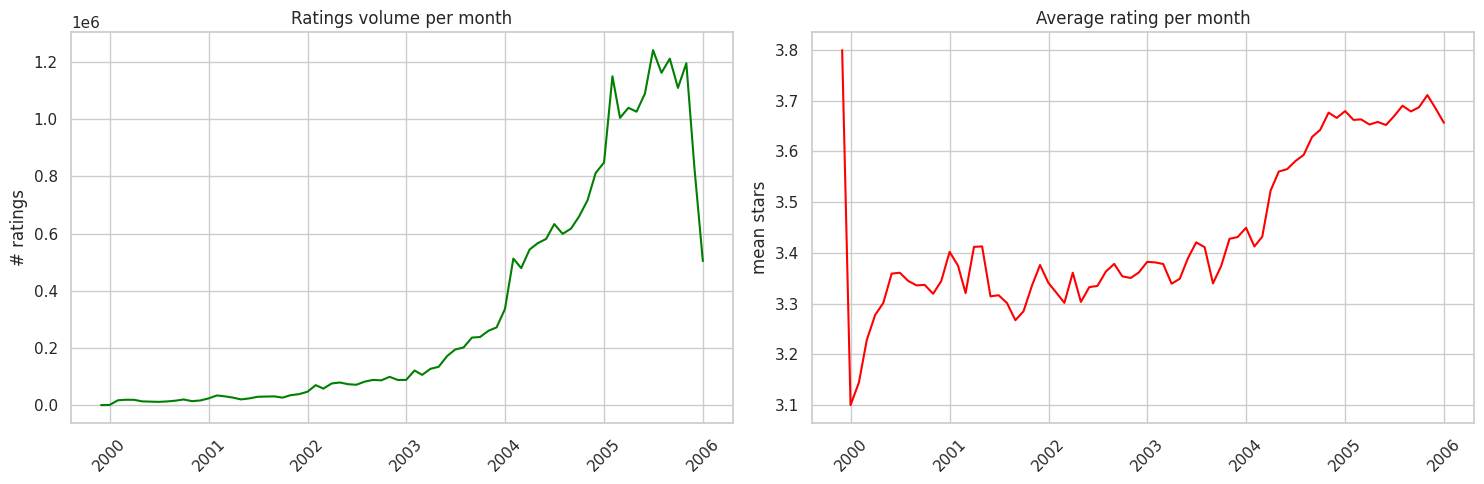

In [12]:
monthly = ratings.set_index('date').resample('ME').agg(
    n=('rating','size'), avg=('rating','mean'))
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(monthly.index, monthly['n'], color="green")
ax[0].set_title("Ratings volume per month"); ax[0].set_ylabel("# ratings")
ax[1].plot(monthly.index, monthly['avg'], color="red")
ax[1].set_title("Average rating per month"); ax[1].set_ylabel("mean stars")
for a in ax: a.tick_params(axis='x', rotation=45)
save("temporal_trends.png"); plt.show()

**Observation.** Rating **volume grows sharply over time** as Netflix's user
base expanded (a large fraction of all ratings come from the final ~2 years),
while the **average rating drifts upward** modestly. This temporal structure
means a time-aware split (or at least awareness of recency) matters; we use a
per-user random holdout but note that recency could be exploited further.

## 7. Mean rating vs. popularity
Are popular movies also rated more highly?

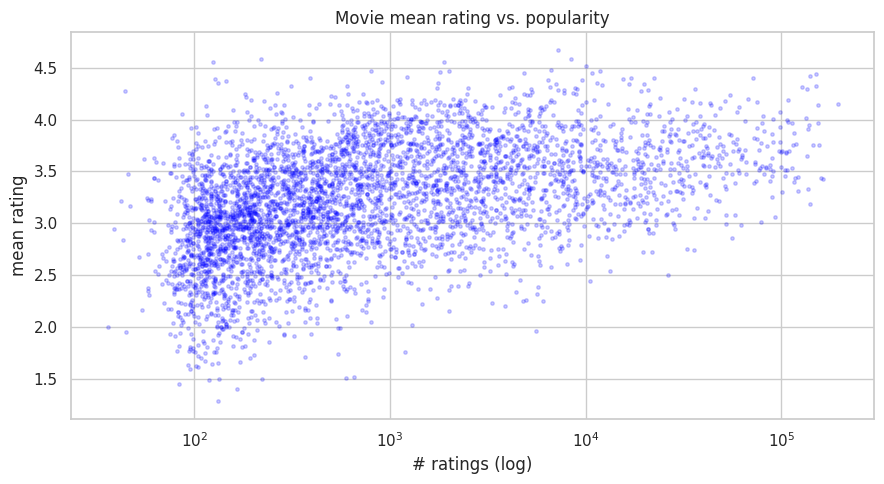

Correlation (log popularity vs mean rating): 0.454


In [13]:
movie_stats = ratings.groupby('movie_id')['rating'].agg(['mean','size'])
plt.figure(figsize=(9,5))
plt.scatter(movie_stats['size'], movie_stats['mean'], s=6, alpha=0.2, color="blue")
plt.xscale('log')
plt.xlabel("# ratings (log)"); plt.ylabel("mean rating")
plt.title("Movie mean rating vs. popularity")
save("rating_vs_popularity.png"); plt.show()
print("Correlation (log popularity vs mean rating):",
      round(np.corrcoef(np.log(movie_stats['size']), movie_stats['mean'])[0,1], 3))

**Observation.** There is a mild positive relationship — widely-rated movies
tend to be rated a little higher (popularity and quality are correlated, plus a
selection effect), but the spread is large: niche films span the full quality
range. Popularity alone is a weak signal for *personalized* quality, reinforcing
the need for collaborative filtering.

## 8. Summary of key insights

| # | Insight | Modelling implication |
|---|---------|----------------------|
| 1 | Ratings skew positive (mean ≈ 3.6; 4★ most common) | Bias baseline is strong; relevance threshold 3.5 ≈ "4★ and up" |
| 2 | User activity is long-tailed (power users dominate) | Filter low-activity users; regularise user terms by support |
| 3 | Movie popularity is long-tailed (few blockbusters) | Track Coverage; CF needed to serve the tail |
| 4 | Matrix is ~99% sparse | Use low-rank matrix factorization (SVD/ALS) |
| 5 | Volume grows over time; mean rating drifts up | Be deliberate about train/test split; recency is informative |
| 6 | Popularity weakly correlates with mean rating | Popularity ≠ personalization; learn latent preferences |

**Business implications.** Personalized recommendation (not popularity charts) is
required to surface relevant content from the long tail and drive engagement; the
sparsity and cold-start realities mean the system must degrade gracefully for new
users/items (e.g. fall back to bias/popularity baselines).

These findings directly shape the modelling phase: we build a **bias baseline**,
**item-based KNN CF**, **Funk-SVD** and **ALS** matrix factorization, and evaluate
them on both rating accuracy (RMSE) and ranking quality (MAP@10).